In [1]:
import os
from pyhere import here

project_dir = here(".")
os.chdir(project_dir)

print(os.getcwd())


/Users/work/Data Science/sheffield-bats


In [2]:
%load_ext autoreload
%autoreload 2

import json

import elapid as ela
import geopandas as gpd
import rioxarray as rxr

from sklearn.metrics import roc_auc_score
from folium import Map, GeoJson, CircleMarker
from matplotlib import pyplot as plt


from sdm.models.utils.utils import prepare_occurrence_data
from sdm.models.maxent.maxent_model import evaluate_and_train_maxent_model
from sdm.raster.io import load_environmental_variables
from sdm.raster.utils import generate_point_grid
from sdm.occurrence.species_data import latin_name, activity_type, genus
from sdm.utils.io import load_config
from sdm.utils.io import load_boundary

from pathlib import Path

In [3]:
# load the config
config = load_config()
config


{'paths': {'raw_data': 'data/raw',
  'processed_data': 'data/processed',
  'models': 'data/sdm_models',
  'predictions': 'data/sdm_predictions',
  'model_config': 'model_config.yml',
  'variables_config': 'variables_config.yml',
  'occurence_data': 'data/processed/bats-tidy.geojson',
  'background_points': 'data/processed/background-points.geojson',
  'boundary': 'data/processed/boundary.geojson',
  'grid_points': 'data/evs/grid-points.parquet',
  'evs': 'data/processed/evs',
  'ev_tiff': 'data/evs/evs-to-model.tif'},
 'spatial': {'top': 646900,
  'left': 313000,
  'crs': 'EPSG:27700',
  'resolution': 100,
  'study_area_buffer': 7000},
 'crs': 'EPSG:27700',
 'mlflow': {'tracking_uri': 'sqlite:///mlflow.db',
  'experiment_name': 'species_sdm_experiment'}}

In [4]:
import topojson as tp

boundary = load_boundary(
    filepath=config["paths"]["boundary"], buffer_distance=0, target_crs=27700
)

# simplify the boundary to regions to make the calculation faster
boundary_tp = tp.Topology(boundary, prequantize=True)
boundary_tp.toposimplify(100, inplace=True)
boundary = boundary_tp.to_gdf()
boundary["geometry"] = boundary.geometry.make_valid()
boundary["geometry"] = boundary.geometry.buffer(0)


boundary_4326 = boundary.to_crs(4326)
boundary_4326

,geometry,County
0,"MULTIPOLYGON (((-0.92927 53.77354, -0.93328 53...",East Riding of Yorkshire
1,"MULTIPOLYGON (((-0.78862 54.56019, -0.78826 54...",North Yorkshire
2,"POLYGON ((-1.82224 53.52109, -1.80427 53.537, ...",South Yorkshire
3,"POLYGON ((-1.82224 53.52109, -1.82714 53.52349...",West Yorkshire


# Environmental Variables

In [5]:
evs_to_model, ev_path = load_environmental_variables(config["paths"]["ev_tiff"])

all_env_var_names = list(evs_to_model.data_vars.keys())
evs_to_model

<xarray.Dataset> Size: 513MB
Dimensions:                                  (x: 1930, y: 1544)
Coordinates:
  * x                                        (x) float64 15kB 3.562e+05 ... 5...
  * y                                        (y) float64 12kB 3.716e+05 ... 5...
    spatial_ref                              int64 8B 0
Data variables: (12/43)
    climate_stats_temp_ann_var               (y, x) float32 12MB ...
    climate_bioclim_bio_7                    (y, x) float32 12MB ...
    terrain_dtm                              (y, x) float32 12MB ...
    climate_stats_prec_ann_avg               (y, x) float32 12MB ...
    climate_stats_temp_ann_avg               (y, x) float32 12MB ...
    ceh_landcover_wetland                    (y, x) float32 12MB ...
    ...                                       ...
    vom_vegetation_height_mean_500m          (y, x) float32 12MB ...
    ceh_landcover_suburban_500m              (y, x) float32 12MB ...
    os_cover_water_500m                      (y, x) float32 12MB ...
    ceh_landcover_coniferous_woodland_500m   (y, x) float32 12MB ...
    ceh_landcover_urban_500m                 (y, x) float32 12MB ...
    ceh_landcover_improved_grassland_500m    (y, x) float32 12MB ...
Attributes:
    AREA_OR_POINT:  Area

In [6]:
## Convert the env vars to a dataframe to make it easy to join with occurence

ev_df = evs_to_model.to_dataframe()
ev_df.reset_index(inplace=True)
ev_gdf = gpd.GeoDataFrame(ev_df, geometry=gpd.points_from_xy(ev_df.x, ev_df.y))
ev_gdf.crs = evs_to_model.rio.crs
ev_gdf = ev_gdf.drop(columns=["spatial_ref"])
ev_gdf.rename(columns={"x": "grid_x", "y": "grid_y"}, inplace=True)

# Drop rows with missing values - can't be used for modelling
# TODO: interpolate missing values
ev_gdf.dropna(inplace=True)

ev_gdf.head()


,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_7,terrain_dtm,climate_stats_prec_ann_avg,climate_stats_temp_ann_avg,ceh_landcover_wetland,os_distance_distance_to_buildings,climate_bioclim_bio_9,...,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m,geometry
8703,356750.0,469950.0,4.159956,17.891073,59.227085,111.416664,8.851787,0.0,56.832912,10.356260,...,35.0,10.457754,762.0,0.960688,335.0,1.16,5.0,22.0,8718.0,POINT (356750 469950)
8704,356750.0,470050.0,4.159015,17.890902,71.512306,111.666664,8.850486,0.0,27.807781,10.349444,...,35.0,10.673230,824.0,1.024941,335.0,1.31,5.0,14.0,8664.0,POINT (356750 470050)
8705,356750.0,470150.0,4.158071,17.890728,81.863503,111.750000,8.849172,0.0,55.940475,10.342648,...,40.0,11.073326,936.0,1.124981,335.0,1.56,5.0,14.0,8547.0,POINT (356750 470150)
8706,356750.0,470250.0,4.157125,17.890556,89.127396,112.000000,8.847846,0.0,132.400299,10.335870,...,50.0,11.196786,1040.0,1.201037,339.0,1.84,5.0,14.0,8429.0,POINT (356750 470250)
8707,356750.0,470350.0,4.156174,17.890383,87.964066,112.250000,8.846507,0.0,177.351807,10.329110,...,95.0,10.799233,1045.0,1.181763,339.0,1.95,5.0,14.0,8406.0,POINT (356750 470350)


# Load the Occurence

In [7]:
# load the occurrence data
bat_records = gpd.read_file(config["paths"]["occurence_data"])
bat_records = bat_records[bat_records.accuracy <= 100]




from leafmap.deckgl import Map

map_center = boundary_4326.union_all().centroid
m = Map(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 40],
)

m.add_gdf(
    bat_records,
    zoom_to_layer=False,
    get_radius=500,
    # pink
    get_fill_color=[255, 192, 203, 180],
)

m


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 40], table=arro3.core.Table
+…

<Axes: >

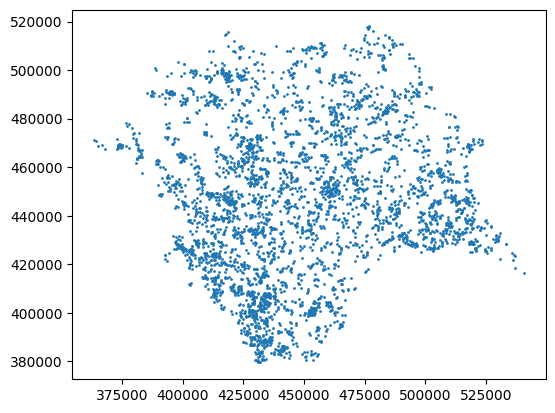

In [ ]:
from sdm.occurrence.sampling import (
    generate_background_points_from_data,
    BackgroundMethod,
    TransformMethod,
)
## This is too slow
# TODO: make it faster
activity_type = "In flight"
# genrate the background points
background_points, density_array = generate_background_points_from_data(
    occurrence_data=bat_records[bat_records.activity_type == activity_type],
    boundary=boundary,
    n_background_points=4000,
    background_method=BackgroundMethod.CONTRAST,
    background_value=0.00,
    sigma=6.5,
    transform_method=TransformMethod.PRESENCE,
    #region_weighting_factor=0.5,
    clip_to_boundary=True,
)

background_points.rename(columns={"presence": "class"}, inplace=True)

background_points.plot(
    markersize=1,
)

In [49]:
# use leafmap foliumap to plot the map
from leafmap.foliumap import Map
from folium import GeoJson, CircleMarker


centroid = boundary_4326.union_all().centroid
m = Map(location=[centroid.y, centroid.x], zoom_start=8, tiles="CartoDB positron")

# Add boundary
GeoJson(
    boundary, style_function=lambda x: {"fillColor": "none", "color": "black"}
).add_to(m)


# Add background points
GeoJson(
    background_points,
    style_function=lambda x: {
        "fillColor": "green",
        "color": "green",
        "radius": 3,
        "fillOpacity": 1,
        "weight": 0.5,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

# Add bats points
GeoJson(
    bat_records[["geometry"]],
    style_function=lambda x: {
        "color": "orange",
        "fillColor": "orange",
        "radius": 3,
        "weight": 0.5,
        "fillOpacity": 1,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

m


## Prepare Training Data

In [50]:
split_keys = ["latin_name", "activity_type"]

bat_records = bat_records[
    split_keys + ["geometry"]
]
bat_records["class"] = 1
bat_records[split_keys].value_counts().to_frame()


count
latin_name                activity_type       
Pipistrellus pipistrellus Roost           4075
                          In flight       3258
Plecotus auritus          Roost           1548
Pipistrellus pygmaeus     Roost           1067
Myotis nattereri          Roost            707
Pipistrellus pygmaeus     In flight        602
Nyctalus noctula          In flight        559
Myotis daubentonii        In flight        441
                          Roost            424
Nyctalus noctula          Roost            273
Myotis mystacinus         Roost            249
Plecotus auritus          In flight        225
Nyctalus leisleri         In flight        172
Myotis nattereri          In flight         72
Nyctalus leisleri         Roost             50
Myotis brandtii           Roost             47
Myotis mystacinus         In flight         39
Pipistrellus nathusii     Roost             32
                          In flight         15
Myotis brandtii           In flight         13
Eptesicus serotinus       In flight          4
Vespertilio murinus       In flight          1

In [51]:
## Annotate the points with the environmental variables
resolution = evs_to_model.rio.resolution()
tolerance = abs(resolution[0])

occurence_data = gpd.sjoin_nearest(bat_records, ev_gdf, how="inner",  max_distance=tolerance)
background_data = gpd.sjoin_nearest(background_points, ev_gdf, how="inner",  max_distance=tolerance)

occurence_data.drop(columns=["index_right"], inplace=True)
background_data.drop(columns=["index_right"], inplace=True)

occurence_data.head()




,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_7,terrain_dtm,climate_stats_prec_ann_avg,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
0,Nyctalus noctula,In flight,POINT (465350 457750),1,465350.0,457750.0,4.370765,19.998690,17.848902,50.666668,...,0.0,1236.0,10.552817,1450.0,2.058665,139.0,2.73,391.0,20.0,6621.0
1,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,19.274574,29.562792,53.916668,...,2.0,2161.0,11.823381,2267.0,1.776723,49.0,25.67,73.0,140.0,2726.0
2,Nyctalus noctula,In flight,POINT (446450 435450),1,446450.0,435450.0,4.431757,20.190638,32.155224,52.666668,...,0.0,8152.0,4.328964,312.0,0.395401,129.0,0.99,0.0,122.0,1210.0
3,Nyctalus noctula,In flight,POINT (439650 467050),1,439650.0,467050.0,4.357553,19.600000,13.160098,51.833332,...,0.0,1258.0,12.764629,339.0,1.336935,4514.0,5.96,0.0,1527.0,2002.0
4,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,19.274574,29.562792,53.916668,...,2.0,2161.0,11.823381,2267.0,1.776723,49.0,25.67,73.0,140.0,2726.0


In [52]:
background_data.head()

,geometry,class,density,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_7,terrain_dtm,climate_stats_prec_ann_avg,climate_stats_temp_ann_avg,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
0,POINT (453741.203 402053.071),0,0.000004,453750.0,402050.0,4.482922,20.660053,45.976013,53.500000,9.397600,...,1.0,1634.0,12.051138,727.0,1.262560,5363.0,2.47,21.0,207.0,1793.0
1,POINT (502041.203 439853.071),0,0.000003,502050.0,439850.0,4.385686,19.188562,28.547789,53.166668,9.447710,...,0.0,1026.0,7.175530,425.0,0.675792,527.0,0.87,0.0,115.0,7907.0
2,POINT (427041.203 463353.071),0,0.000002,427050.0,463350.0,4.242716,18.900000,133.000397,67.666664,8.642181,...,0.0,259.0,8.412813,226.0,0.816432,461.0,2.78,22.0,258.0,8774.0
4,POINT (408341.203 428353.071),0,0.000003,408350.0,428350.0,4.280074,18.433693,198.416519,91.500000,8.802348,...,969.0,4.0,7.458243,389.0,0.367420,2887.0,0.44,36.0,1584.0,3739.0
5,POINT (430941.203 402653.071),0,0.000003,430950.0,402650.0,4.351320,19.254932,172.422684,75.333336,8.871076,...,4.0,1331.0,10.662173,1467.0,1.857042,779.0,0.46,160.0,14.0,6235.0


In [84]:
def get_presence_data(
    presence : gpd.GeoDataFrame,
    latin_name : str,
    activity_type : str,
):
    chunk = presence[
        (presence.activity_type == activity_type) &
        (presence.latin_name == latin_name)
    ]
    return chunk

def drop_duplicates(
    gdf : gpd.GeoDataFrame,
    index_cols = ["grid_x", "grid_y"],
):
    gdf = gdf.drop_duplicates(subset=index_cols)
    return gdf

latin_name = "Myotis daubentonii"
activity_type = activity_type

species_presence = get_presence_data(
    occurence_data,
    latin_name,
    activity_type,
)

species_presence = drop_duplicates(species_presence)

species_presence.head()



,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_7,terrain_dtm,climate_stats_prec_ann_avg,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
5426,Myotis daubentonii,Roost,POINT (428050 469450),1,428050.0,469450.0,4.245035,18.900002,79.511322,61.583332,...,140.0,67.0,23.665859,1391.0,3.867964,85.0,5.81,21.0,14.0,7695.0
5432,Myotis daubentonii,Roost,POINT (433250 470250),1,433250.0,470250.0,4.328190,19.400000,18.213825,52.500000,...,0.0,4897.0,8.978715,124.0,0.715464,249.0,8.96,0.0,168.0,3802.0
5439,Myotis daubentonii,Roost,POINT (422650 481250),1,422650.0,481250.0,4.194801,18.858521,74.368149,61.083332,...,0.0,803.0,9.772939,321.0,0.569441,1504.0,5.75,0.0,355.0,6578.0
5474,Myotis daubentonii,Roost,POINT (431850 472150),1,431850.0,472150.0,4.322017,19.395395,24.647644,53.500000,...,0.0,1599.0,16.109074,577.0,2.094708,2764.0,5.27,4.0,449.0,4103.0
5476,Myotis daubentonii,Roost,POINT (401050 488650),1,401050.0,488650.0,4.185853,18.503529,189.464310,90.750000,...,77.0,10.0,14.362227,2102.0,1.067058,643.0,4.89,120.0,64.0,6516.0


In [85]:
from typing import List, Optional
def grid_sample(
    gdf : gpd.GeoDataFrame,
    stratify_cols : Optional[List[str]] = None,
    grid_size_x : float = 100,
    grid_size_y : float = 100,
) -> gpd.GeoDataFrame:
    """
    Get a sample of points stratified by the stratify_cols so there is
    one point per grid cell per stratify_cols group
    """
    gdf = gdf.copy()
    centroids = gdf.geometry.centroid

    x_bins = (centroids.x // grid_size_x).astype(int)
    y_bins = (centroids.y // grid_size_y).astype(int)

    gdf["_x_bin"] = x_bins
    gdf["_y_bin"] = y_bins

    if stratify_cols is None:
        stratify_cols = []

    gdf = gdf.groupby(stratify_cols + ["_x_bin", "_y_bin"]).apply(
        lambda x: x.sample(1)
    )
    gdf.drop(columns=["_x_bin", "_y_bin"], inplace=True)
    return gdf


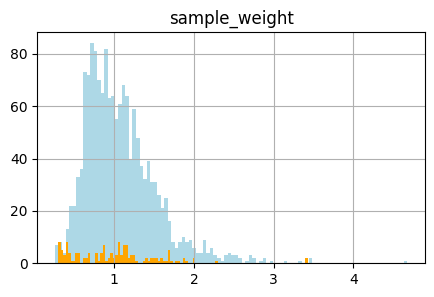

In [86]:
from shapely import distance
import numpy as np
def get_distance_matrix(
    a : gpd.GeoSeries,
    b : gpd.GeoSeries,
):
    A = a.array.to_numpy()
    B = b.array.to_numpy()

    dist_mat = distance(A[:, None], B[None, :])
    return dist_mat



dmax_by_species_m = {
    "Pipistrellus pipistrellus": 3000,   # very common, short-range forager
    "Pipistrellus pygmaeus":     3000,
    "Pipistrellus nathusii":     4000,   # more mobile pipistrelle

    "Plecotus auritus":          3000,   # typical 2–3 km range

    "Myotis daubentonii":        3000,   # riparian, but rarely >3 km from water/roost
    "Myotis nattereri":          3500,
    "Myotis mystacinus":         3000,
    "Myotis brandtii":           3000,

    "Nyctalus noctula":          6000,   # big, fast, wide-ranging
    "Nyctalus leisleri":         6000,

    "Eptesicus serotinus":       6000,   # similar movement ecology to Nyctalus
    "Vespertilio murinus":       7000,   # most mobile of the group
}

sort_density = False
limit_to_range = True
grid_size_m = 500


d_min = 500
d_max = np.Inf #dmax_by_species_m[latin_name]

p_dist = get_distance_matrix(
    species_presence.geometry,
    background_data.geometry,
).min(axis=0)

n_max = len(species_presence) * 10

if limit_to_range:
    # get background points within the distance range
    species_absence = background_data[
        (p_dist >= d_min) &
        (p_dist <= d_max)
    ]
else:
    species_absence = background_data

species_absence = drop_duplicates(species_absence)




species_presence = grid_sample(
    species_presence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)

species_absence = grid_sample(
    species_absence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)



if sort_density:
    species_absence = species_absence.sort_values(
        by = "density",
        ascending = False,
    ).head(n_max)
else:
    species_absence = species_absence.sample(n=min(len(species_absence), n_max), replace=False)


# get the sample weights
species_presence["sample_weight"] = ela.distance_weights(
    species_presence.geometry,
    n_neighbors=10,
)
species_absence["sample_weight"] = ela.distance_weights(
    species_absence.geometry,
    n_neighbors=10,
)
fig, ax = plt.subplots(figsize=(5, 3))
species_absence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="lightblue",
)
species_presence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="orange",
)

plt.show()


In [87]:
from leafmap.deckgl import Map as DeckMap



map_center = boundary_4326.union_all().centroid
m = DeckMap(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 30],
)


m.add_gdf(
    species_absence,
    zoom_to_layer=False,
    # black
    get_fill_color=[0, 0, 0, 180],
    get_radius=100,
)  
m.add_gdf(
    species_presence,
    zoom_to_layer=False,
    get_radius=100,
    # orange
    get_fill_color=[255, 165, 0, 180],
)

print(
    f"There are {len(species_presence)} presence points and {len(species_absence)} background points for {latin_name} - {activity_type}"
)
m


There are 139 presence points and 1570 background points for Myotis daubentonii - Roost


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 30], table=arro3.core.Table
+…

In [88]:
from typing import Any


import pandas as pd
species_data = pd.concat([species_presence, species_absence])
columns = [
    "class",
    "sample_weight",
    "geometry",
] + list(evs_to_model.data_vars.keys())
species_data = species_data[columns]
species_data.head()

,,,class,sample_weight,geometry,climate_stats_temp_ann_var,climate_bioclim_bio_7,terrain_dtm,climate_stats_prec_ann_avg,climate_stats_temp_ann_avg,ceh_landcover_wetland,os_distance_distance_to_buildings,...,ceh_landcover_grassland_500m,ceh_landcover_arable_500m,vom_vegetation_height_max_500m,ceh_landcover_broadleaved_woodland_500m,vom_vegetation_height_mean_500m,ceh_landcover_suburban_500m,os_cover_water_500m,ceh_landcover_coniferous_woodland_500m,ceh_landcover_urban_500m,ceh_landcover_improved_grassland_500m
_x_bin,_y_bin,,,,,,,,,,,,,,,,,,,,,,
761,924,6337,1,1.441019,POINT (380950 462150),4.258001,18.542065,129.791031,99.416664,8.588567,0.0,134.782669,...,10.0,509.0,8.916798,725.0,0.974974,176.0,3.29,0.0,56.0,8516.0
764,932,6258,1,1.461911,POINT (382350 466350),4.242624,18.603411,189.937180,109.750000,8.179720,0.0,105.813141,...,778.0,242.0,12.458793,1213.0,1.778141,289.0,2.46,160.0,196.0,6927.0
775,981,5922,1,2.002266,POINT (387650 490650),4.226759,18.600000,227.672318,103.500000,7.857603,0.0,101.737274,...,587.0,78.0,8.923540,316.0,0.856327,446.0,6.04,408.0,9.0,7978.0
780,925,9536,1,1.050094,POINT (390063.5 462688.5),4.258241,18.495827,194.121140,104.916664,8.196500,0.0,81.730339,...,687.0,32.0,8.643098,67.0,0.537085,634.0,1.53,4.0,69.0,8495.0
782,897,6403,1,1.084626,POINT (391150 448750),4.232752,18.300001,141.425064,93.333336,8.692128,0.0,122.516357,...,41.0,47.0,14.480915,782.0,1.204271,826.0,2.12,6.0,20.0,8238.0


# Modelling

In [89]:
from sdm.models.maxent.maxent_model import (
    create_maxent_pipeline,
    get_feature_config,
    ActivityType,
    DefaultMaxentConfig,
)
import yaml

feature_config_path = "data/sdm_models/tuning/best_variables_config.yml"

with open(feature_config_path, "r") as f:
    feature_config = yaml.safe_load(f)
#feature_config = get_feature_config()
feature_config = feature_config["variables"]["activity_feature_sets"]

features_to_model = feature_config[activity_type]


model_config = DefaultMaxentConfig(
    feature_types=["linear", "hinge"],
    beta_multiplier=4.0,
    beta_lqp=1.0,
    beta_hinge=1.0,
    beta_threshold=1.0,
    clamp=False,
    class_weights="balanced",
    n_hinge_features=10,
    n_threshold_features=10,
)

maxent_model = create_maxent_pipeline(
    feature_names=features_to_model,
    maxent_n_jobs=-1,
    model_config=model_config,
)

maxent_model


Pipeline(steps=[('feature_selection',
                 FeatureSubsetter(feature_names=['climate_stats_wind_ann_avg',
                                                 'terrain_dtm',
                                                 'climate_stats_temp_ann_avg',
                                                 'climate_bioclim_bio_3',
                                                 'os_distance_distance_to_buildings',
                                                 'vom_vegetation_height_max',
                                                 'os_cover_water',
                                                 'terrain_stats_aspect_northness_slope',
                                                 'terrain_stats_tpi',
                                                 'os_distance_distance_to_major_roads',
                                                 'ceh_la...
                                                 'ceh_landcover_grassland_500m',
                                                 'ceh_landcover_urban_500m',
                                                 'ceh_landcover_coniferous_woodland_500m',
                                                 'bgs_coast_distance_to_coast',
                                                 'climate_stats_temp_ann_var',
                                                 'terrain_stats_roughness',
                                                 'ceh_landcover_broadleaved_woodland'])),
                ('scaling', StandardScaler()),
                ('maxent',
                 MaxentModel(beta_multiplier=4.0, clamp=False,
                             class_weights='balanced',
                             feature_types=['linear', 'hinge'], n_cpus=-1))])

In [90]:
import mlflow


def to_percent(x):
    return (x * 100).round(1)


# Configure MLflow from project config so we use the same tracking store/experiment
tracking_uri = config["mlflow"]["tracking_uri"]
experiment_name = config["mlflow"]["experiment_name"]
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(experiment_name)


with mlflow.start_run():
    final_model, cv_models, cv_scores = evaluate_and_train_maxent_model(
        model=maxent_model,
        occurrence_gdf=species_data,
        metric_fn=roc_auc_score,
        n_cv_folds=3,
    )

    mlflow.log_metric("mean_auc", cv_scores.mean())
    mlflow.log_metric("std_auc", cv_scores.std())

    mlflow.log_params(
        {
            "latin_name": latin_name,
            "activity_type": activity_type,
            "n_presence": len(species_presence),
            "n_background": len(species_absence),
            "feature_names": features_to_model,
        }
    )


print(f"Mean AUC: {to_percent(cv_scores.mean())}%")
print(f"Variation: +/- {to_percent(cv_scores.std())}%")

Mean AUC: 73.0%
Variation: +/- 6.6%


In [91]:
model_id = f"{latin_name}-{activity_type}"

In [92]:
from sdm.models.maxent.maxent_model import apply_models_to_raster

prediction_paths = []
# Define the arguments for each task

path_predict = Path(f"data/temp/prediction-{latin_name}-{activity_type}.tif")
path_predict.parent.mkdir(parents=True, exist_ok=True)

apply_models_to_raster(
    models={
        model_id: final_model,
    },
    raster_path=ev_path,
    output_path=str(path_predict),
    windowed=True,
    window_size=512,
)


Processing windows:   0%|                              | 0/16 [00:00<?, ?it/s]

In [93]:
from rasterio.mask import mask
import numpy as np
import rasterio as rio
import rioxarray as rxr

# mask the prediction raster with the boundary
predictions_masked = Path(
    f"data/temp/prediction-{latin_name}-{activity_type}-masked.tif"
)

predictions = rxr.open_rasterio(path_predict)
predictions = predictions.rio.clip_box(*tuple(boundary.total_bounds))
predictions = predictions.rio.reproject(4326)
predictions.rio.to_raster(predictions_masked)

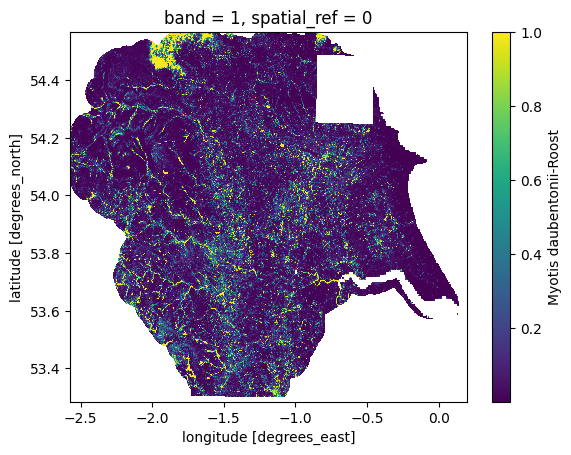

In [94]:
predictions.where(predictions > 0.0).plot()

In [95]:
import leafmap

m = leafmap.Map()
m.zoom_to_gdf(boundary_4326)
m.add_basemap("HYBRID")
m.add_raster(
    str(predictions_masked),
    layer_name="Predictions",
    cmap="viridis",
    nodata=np.nan,
    opacity=0.5,
)
m.add_gdf(
    species_presence,
    layer_name="Presence",
    point_style={"color": "orange", "weight": 1, "opacity": 0.7, "radius": 3},
)
m

Map(center=[53.9258685, -1.187851], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…